In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading Dataset
df=pd.read_csv(r"..\CIC-IDS2017-Dataset\Portscan-Friday-no-metadata.parquet.csv")

In [3]:
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,1266342,41,44,2664,6954,456,0,64.97561,109.864570,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1319353,41,44,2664,6954,456,0,64.97561,109.864570,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,160,1,1,0,0,0,0,0.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1303488,41,42,2728,6634,456,0,66.53658,110.129944,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,77,1,2,0,0,0,0,0.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [4]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 119522
Columns: 78


In [5]:
# Unique Attack Labels
print("Unique Attack Label:")
print(df['Label'].unique())

Unique Attack Label:
<ArrowStringArray>
['Benign', 'PortScan']
Length: 2, dtype: str


In [6]:
#Percentage distribution of attacks
attack_percentage=round(df['Label'].value_counts(normalize=True)*100,2)
print("Attack Percentage Distribution:")
print(attack_percentage)

Attack Percentage Distribution:
Label
Benign      98.36
PortScan     1.64
Name: proportion, dtype: float64


In [7]:
label_count=df['Label'].value_counts()
print(label_count)

Label
Benign      117566
PortScan      1956
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_21760\987887887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


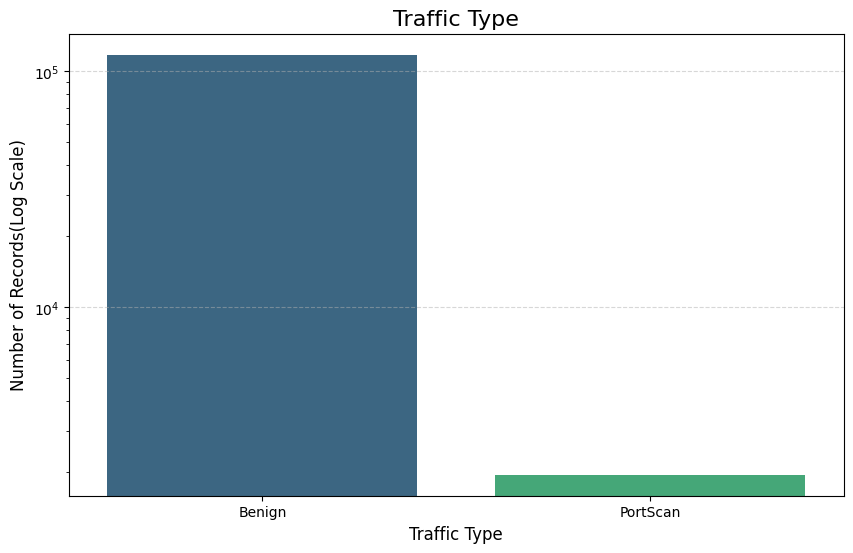

In [8]:
#Visualize the Distribution
plt.figure(figsize=(10,6))
sns.countplot(
    x='Label',
    data=df,
    order=label_count.index,
    palette='viridis'
)
plt.yscale('log')
plt.title('Traffic Type',fontsize=16)
plt.xlabel('Traffic Type',fontsize=12)
plt.ylabel('Number of Records(Log Scale)',fontsize=12)
plt.grid(axis='y',
linestyle='--',alpha=0.5)
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_21760\1577258705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


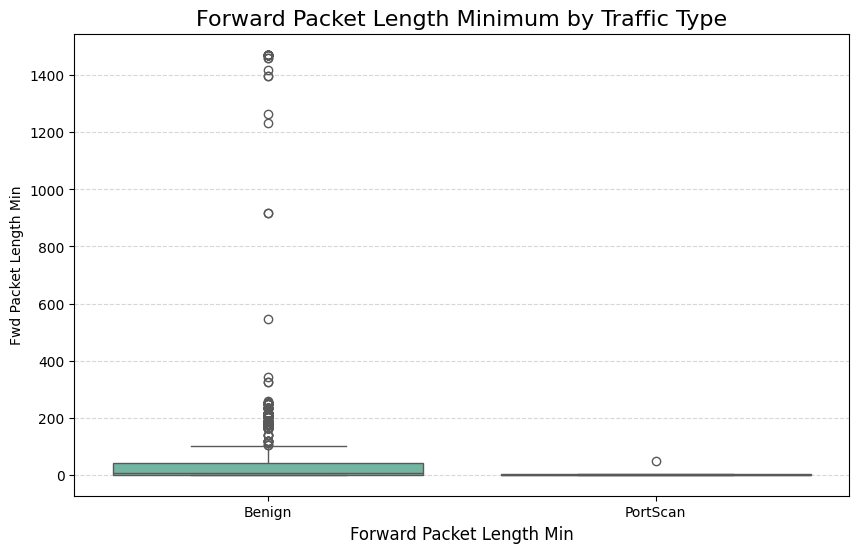

In [9]:
# Forward packet length minimum 
plt.figure (figsize=(10,6))
sns.boxplot(
    data=df,
    x='Label',
    y='Fwd Packet Length Min',
    palette='Set2'
)
plt.title("Forward Packet Length Minimum by Traffic Type",fontsize=16)
plt.xlabel("Forward Packet Length Min",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_21760\2831713225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


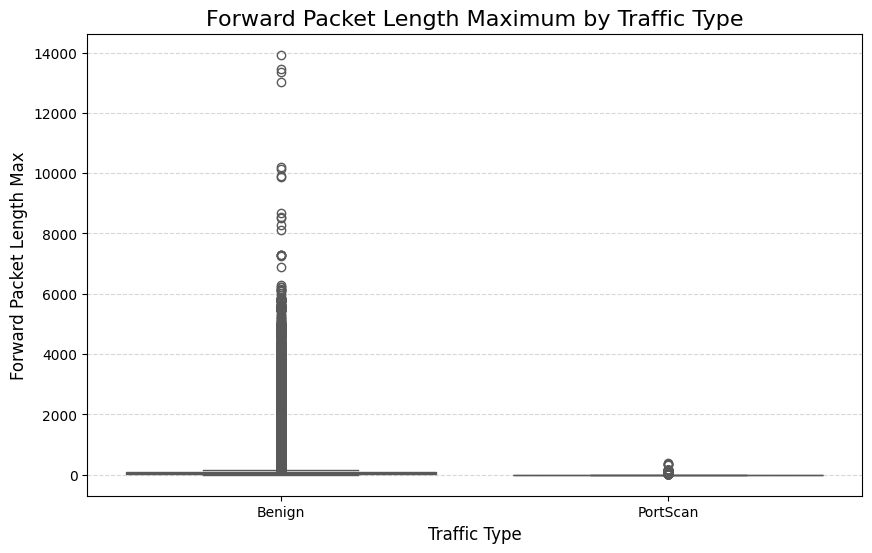

In [10]:
# Forward packet length maximum
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='Label',
    y='Fwd Packet Length Max',
    palette='Set2'
)
plt.title("Forward Packet Length Maximum by Traffic Type",fontsize=16)
plt.xlabel("Traffic Type",fontsize=12)
plt.ylabel("Forward Packet Length Max",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

In [11]:
#Feature Engineering 
# Packet Ratio 
df["Packet Ratio"]=(df["Total Fwd Packets"]/(df["Total Backward Packets"]+1))
df["Packet Ratio"].describe()

count    119522.000000
mean          1.075034
std           3.815990
min           0.008000
25%           0.600000
50%           0.666667
75%           1.125000
max         198.000000
Name: Packet Ratio, dtype: float64

In [12]:
#Zero Data Index
df["Zero Data Index"]=((df["Fwd Packets Length Total"]+df["Bwd Packets Length Total"])==0).astype(int)
df["Zero Data Index"].value_counts()

Zero Data Index
0    109875
1      9647
Name: count, dtype: int64

In [13]:
#Activity Ratio
df["Activity Ratio"]=(
    df["Active Mean"]/(df["Idle Mean"]+1)
)
df["Activity Ratio"].describe()

count    119522.000000
mean          0.007378
std           0.101935
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.969958
Name: Activity Ratio, dtype: float64

In [14]:
# Traffic direction ratio
df["Traffic Direction Ratio"]=(
    df["Total Fwd Packets"]/(
        df["Total Backward Packets"]+df["Total Backward Packets"]+1
    )
)
df["Traffic Direction Ratio"].describe()

count    119522.000000
mean          0.778996
std           3.827001
min           0.004016
25%           0.333333
50%           0.400000
75%           0.615385
max         198.000000
Name: Traffic Direction Ratio, dtype: float64

In [15]:
#Packet Rate
df["Packet Rate"]=(df["Total Fwd Packets"]+df["Total Backward Packets"])/(df["Flow Duration"]+1)
df["Packet Rate"].describe()

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.195220e+05
mean              inf
std               NaN
min     -2.000000e+00
25%      6.822314e-06
50%      8.489865e-05
75%      1.619433e-02
max               inf
Name: Packet Rate, dtype: float64

In [16]:
# Mathematical Boundary Scaling (Log Transformation)
df["Flow Duration Log"] = np.log1p(df["Flow Duration"])
df["Flow IAT Mean Log"] = np.log1p(df["Flow IAT Mean"])
df["Flow Bytes_s Log"] = np.log1p(df["Flow Bytes/s"])
df["Flow Packets_s Log"] = np.log1p(df["Flow Packets/s"])

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\App

In [17]:
df[[
    "Flow Duration Log",
    "Flow IAT Mean Log",
    "Flow Bytes_s Log",
    "Flow Packets_s Log"
]].head()

,Flow Duration Log,Flow IAT Mean Log,Flow Bytes_s Log,Flow Packets_s Log
0,14.051644,9.620893,8.935391,4.221307
1,14.092653,9.661899,8.894387,4.180912
2,5.081404,5.081404,0.000000,9.433564
3,14.080555,9.673898,8.879510,4.169379
4,4.356709,3.676301,0.000000,10.570343


In [18]:
#Correlation matrix
corr=df.corr(numeric_only=True)
corr.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Idle Min,Packet Ratio,Zero Data Index,Activity Ratio,Traffic Direction Ratio,Packet Rate,Flow Duration Log,Flow IAT Mean Log,Flow Bytes_s Log,Flow Packets_s Log
Protocol,1.000000,-0.319961,-0.161309,-0.118925,-0.158446,-0.077740,-0.292827,0.625021,-0.090396,-0.323336,...,-0.117143,-0.105758,-0.292382,-0.073222,-0.096160,-0.133060,-0.251431,-0.191335,0.437164,0.172530
Flow Duration,-0.319961,1.000000,0.302747,0.244424,0.246898,0.153907,0.368592,-0.217133,0.111058,0.280495,...,0.623379,0.079094,-0.098482,0.093651,0.061156,-0.092188,0.647432,0.560232,-0.368905,-0.511905
Total Fwd Packets,-0.161309,0.302747,1.000000,0.962471,0.310857,0.950906,0.191200,-0.108333,0.054100,0.118424,...,0.161863,0.118953,-0.039859,0.097792,0.112284,-0.035268,0.239793,0.144846,-0.043118,-0.155322
Total Backward Packets,-0.118925,0.244424,0.962471,1.000000,0.276065,0.980019,0.164738,-0.083302,0.037111,0.093139,...,0.146843,-0.011047,-0.042566,0.066199,-0.014875,-0.034078,0.192309,0.107177,-0.015144,-0.117993
Fwd Packets Length Total,-0.158446,0.246898,0.310857,0.276065,1.000000,0.196706,0.613975,-0.079712,0.608482,0.548745,...,0.105783,0.005512,-0.057356,0.217670,-0.003544,-0.036751,0.215649,0.141663,-0.026721,-0.151184


C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


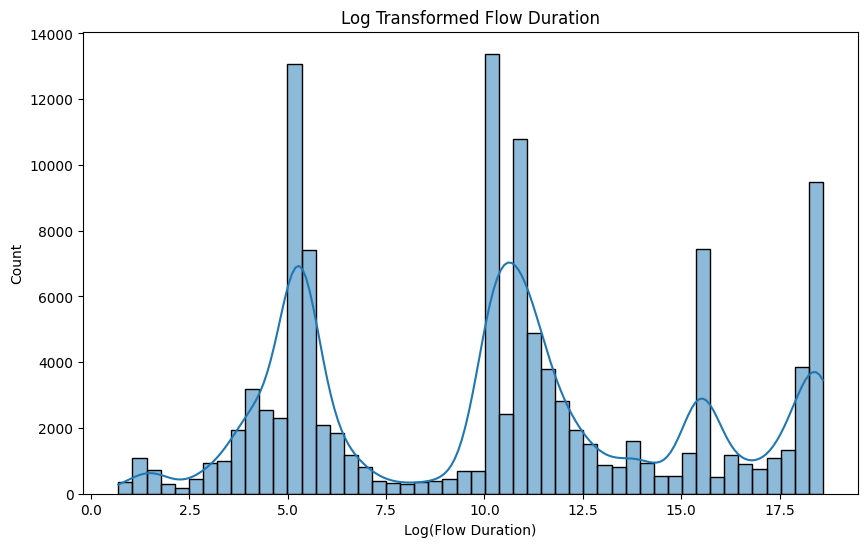

In [19]:
# Flow duration distribution
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df["Flow Duration"]),
    bins=50,
    kde=True
)

plt.title("Log Transformed Flow Duration")
plt.xlabel("Log(Flow Duration)")
plt.show()

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


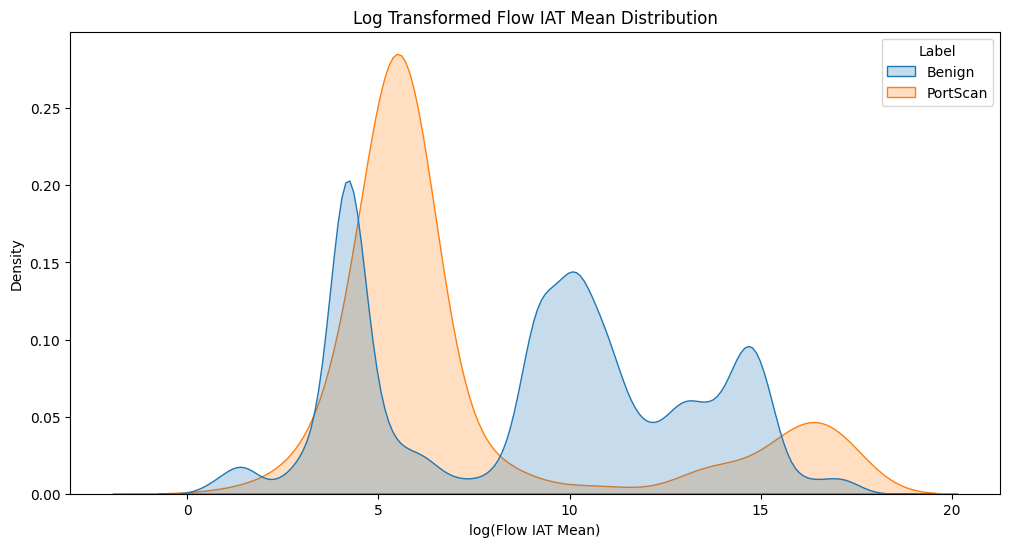

In [20]:
#Tracking Timing and Inter-Arrival Momentum 
plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df,
    x=np.log1p(df["Flow IAT Mean"]),
    hue=df["Label"],
    fill=True,
    common_norm=False
)

plt.title("Log Transformed Flow IAT Mean Distribution")
plt.xlabel("log(Flow IAT Mean)")
plt.ylabel("Density")

plt.show()

In [21]:
#Correlation Heapmap
corr_matrix = df.corr(numeric_only=True)

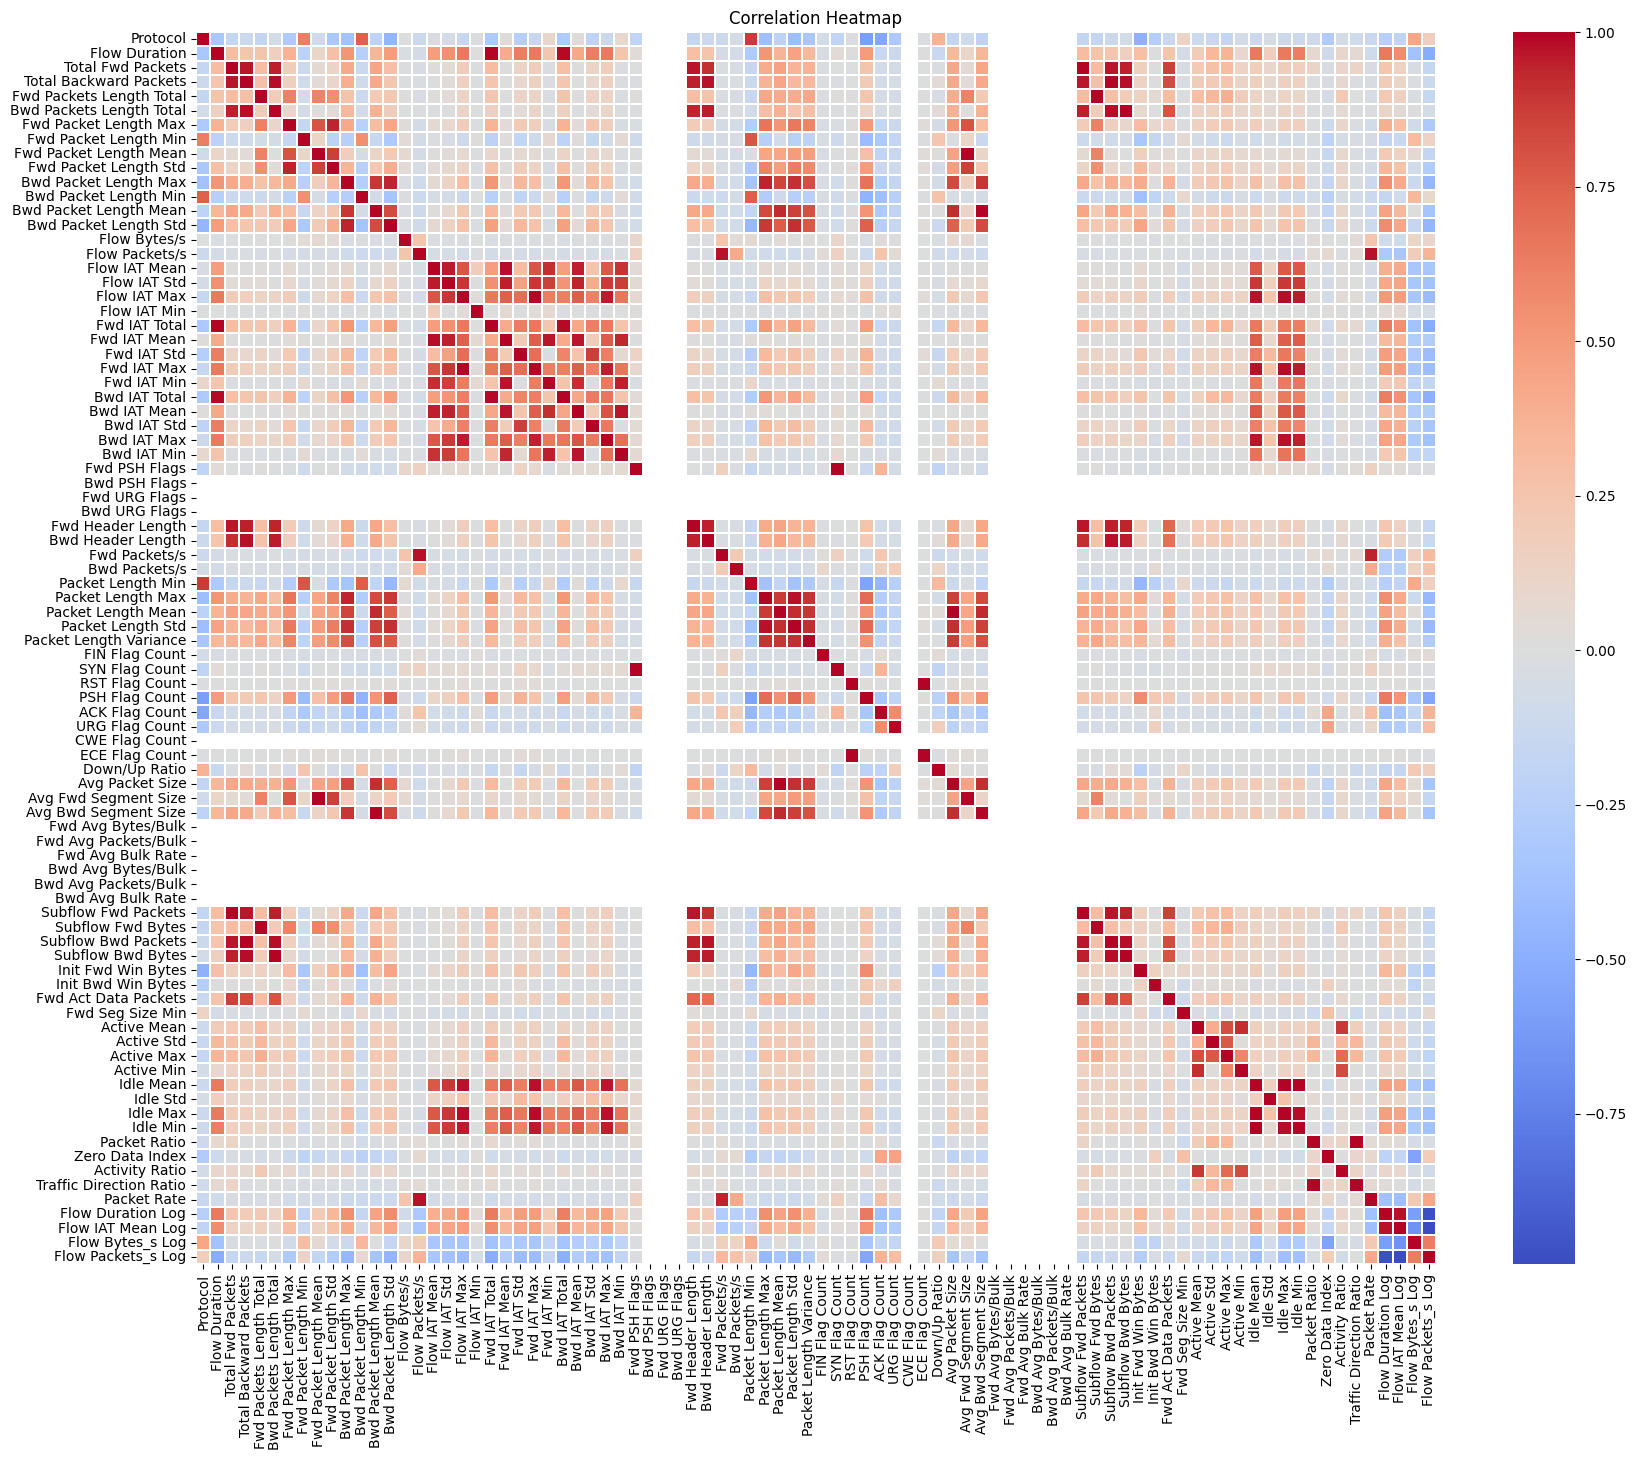

In [22]:
plt.figure(figsize=(20,16))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap")

plt.show()

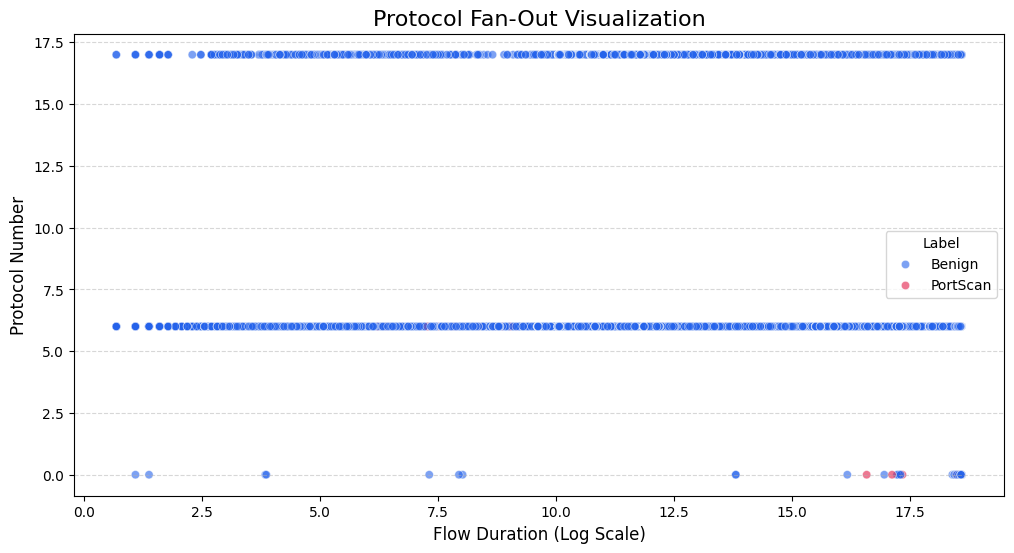

In [23]:
# ==========================================
# Mapping the Destination Port Fan-Out (With Fallback)
# ==========================================
plt.figure(figsize=(12, 6))

df.columns = df.columns.str.strip()

# Check if Destination Port exists; if not, use Protocol as a fallback to avoid crashing
y_column = 'Destination Port' if 'Destination Port' in df.columns else 'Protocol'

sns.scatterplot(
    data=df, 
    x=np.log1p(df['Flow Duration'].clip(lower=1)), 
    y=y_column, 
    hue='Label', 
    alpha=0.6, 
    palette={'Benign': '#2563eb', 'PortScan': '#e11d48'}
)

plt.title(f'{y_column} Fan-Out Visualization', fontsize=16)
plt.xlabel('Flow Duration (Log Scale)', fontsize=12)
plt.ylabel(f'{y_column} Number', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [24]:
# ==========================================
# Feature Engineering (With Fallback)
# ==========================================

# Port Slicing Identifier (Only if Destination Port is present)
if 'Destination Port' in df.columns:
    def categorize_port(port):
        if port <= 1023: return 'System'
        elif port <= 49151: return 'Registered'
        else: return 'Dynamic'
    df['Port Slicing Identifier'] = df['Destination Port'].apply(categorize_port)
else:
    # Fallback category if metadata is missing
    df['Port Slicing Identifier'] = 'Stripped/No-Metadata'

# Mathematical Boundary Scaling (Safe Log Transformations)
df['Flow Duration Log'] = np.log1p(df['Flow Duration'].clip(lower=1))
df['Flow IAT Mean Log'] = np.log1p(df['Flow IAT Mean'].clip(lower=1))

df[['Port Slicing Identifier', 'Flow Duration Log', 'Flow IAT Mean Log']].head()

,Port Slicing Identifier,Flow Duration Log,Flow IAT Mean Log
0,Stripped/No-Metadata,14.051644,9.620893
1,Stripped/No-Metadata,14.092653,9.661899
2,Stripped/No-Metadata,5.081404,5.081404
3,Stripped/No-Metadata,14.080555,9.673898
4,Stripped/No-Metadata,4.356709,3.676301
